In [4]:
#from google.colab import drive

#drive.mount('/content/drive')

#%cd "/content/drive/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26"

In [5]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Dataset Analysis

In [6]:
from ucimlrepo import fetch_ucirepo

try:
    dataset = fetch_ucirepo(id=891)
    # Create pandas DataFrame
    df = dataset.data.original
except ConnectionError as e:  # In case of ucimlrepo failure
    print(f"An error occurred while fetching the dataset: {e}")
    print("Trying with local CSV file...")

    import pandas as pd

    df = pd.read_csv("/MyDrive/1. UniMiB/Magistrale/1° Anno/Machine Learning/ML_25_26dataset/diabetes_binary_health_indicators_BRFSS2015.csv")

In [7]:
df.dtypes

ID                      int64
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [8]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [9]:
# Separate features and target variable
try:
    features = df.drop(columns=["ID", "Diabetes_binary"])
except Exception as e:  # In case of ucimlrepo failure
    print(f"An error occurred while dropping columns: {e}")
    features = df.drop(columns=["Diabetes_binary"])
features.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [10]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64", "float64"]).columns
FEATURES_NUMBER = len(numeric_features)
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [11]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


## Dataset Splitting

In [13]:
from sklearn.model_selection import train_test_split

# 1. Data Preparation
X = scaled_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# PCA

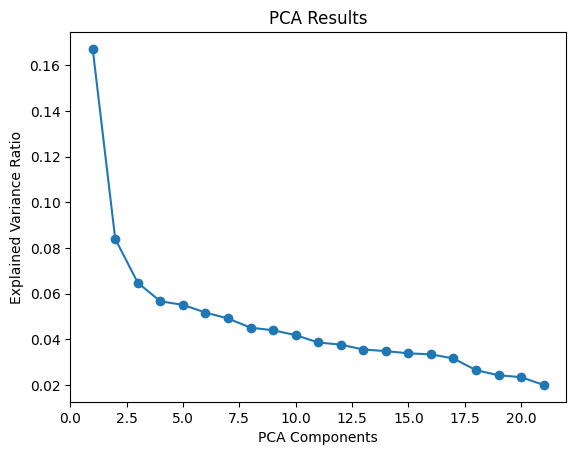

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA().fit(scaled_data)

plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.show()

In [15]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [16]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 80% variance: 14


In [17]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


### PCA Heatmap e Matrice di Covarianza

#### Descrizione
È stata analizzata la relazione tra i componenti principali (PCA) e le feature originali attraverso una heatmap, identificando quali feature originali hanno contribuito maggiormente a ciascun componente principale. Per ogni feature, sono mostrati i pesi su ciascuna componente PCA: a partire da una tonalità molto scura, i colori rappresentano in maniera decrescente l'entità del contributo in una specifica componente principale. Viene così rivelata la distribuzione delle feature nel sottospazio della PCA.

####  Matrice di Covarianza
A giustificazione di quanto ottenuto nella heatmap, la matrice di covarianza mostra che, nella quasi totalità dei casi, le feature sono debolmente correlate fra loro. Ciò suggerisce che la maggior parte delle feature contengono informazioni potenzialmente rilevanti per la predizioni, e quindi da prendere come componente principale nella PCA.

#### Conclusioni
Dai grafici si evince che:
- Heatmap: **non esiste una singola feature dominante** su tutti i componenti principali.
- Matrice di Covarianza: le feature sono tra loro **debolmente correlate**. 
Questo risultati giustificano la necessità di utilizzare **molteplici componenti PCA** (14 su 21) per catturare l'80% della varianza totale. La bassa correlazione tra le feature osservata nella matrice di covarianza si riflette nel fatto che ogni componente PCA raccoglie informazioni da diverse feature, piuttosto che concentrarsi su poche di esse. Questo rende la PCA poco utile nel contesto attuale.

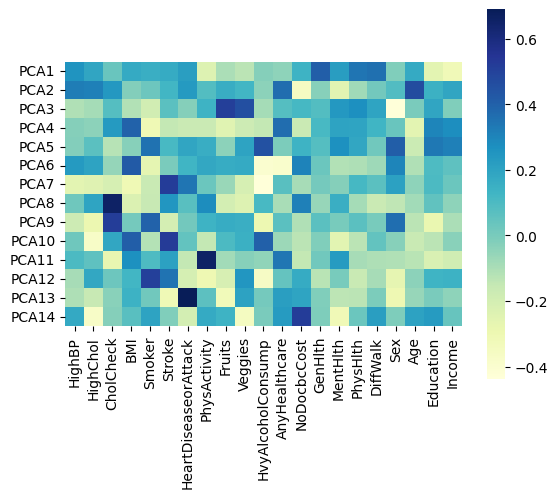

In [18]:
import seaborn as sns

ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")

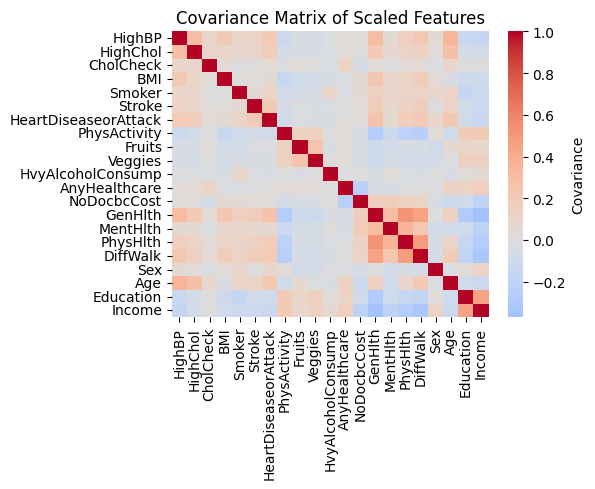

Covariance matrix shape: (21, 21)


In [19]:
import numpy as np

# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

In [20]:
# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

Dimensioni Training Set: (177576, 14)


Dati gli scarsi risultati ottenuti dalla PCA, il lavoro seguente si articola su un confronto con/senza PCA

# Neural Network

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    # Predizioni e binarizzazione
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.show()

    # Report di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcolo ROC-AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Curve di Loss e Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.show()

## No PCA

### Original Features

Architettura della rete neurale:
1) **Input:** tutte le 21 features originali standardizzate
2) **Layer Nascosti:** profondità moderata decrescente (**128 -> 64 -> 32**) come compromesso tra prestazioni e complessità. Come funzione di attivazione viene utilizzata la **ReLU** per ...
3) **Dropout (0.3):** viene ridotto l'overfitting, evitando che la rete dipenda da pattern troppo specifici come nel caso attuale di oun dataset molto sbilanciato verso la classe positiva
4) **Layer Output:** composto da un solo neurone con funzione di attivazione **Sigmoid** per produrre una distribuzione di probabilità tra 0 e 1 per la classe positiva
5) **Funzione di Loss e ottimizzazione:** viene utilizzata **Binary Cross-Entropy** in quanto si sta lavorando su feature binarie standardizzate; **Adam** consente di avere un'apprendimento più "intelligente" grazie al learning-rate adattivo
5) **Epoche (150) e Batch (256):** bilancio tra stabilità dell'ottimizzazione e tempo di training.

In [23]:
# 2. Creazione del Modello
model = Sequential()

# Strati Nascosti
model.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 4. Addestramento
history = model.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8609 - loss: 0.3374 - val_accuracy: 0.8631 - val_loss: 0.3184
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8630 - loss: 0.3230 - val_accuracy: 0.8647 - val_loss: 0.3189
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8637 - loss: 0.3205 - val_accuracy: 0.8647 - val_loss: 0.3180
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.3190 - val_accuracy: 0.8642 - val_loss: 0.3166
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - loss: 0.3185 - val_accuracy: 0.8646 - val_loss: 0.3164
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8648 - loss: 0.3173 - val_accuracy: 0.8652 - val_loss: 0.3159
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8643 - loss: 0.3166 - val_accuracy: 0.8652 - val_loss: 0.3158
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.3165 - val_accu

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 696us/step


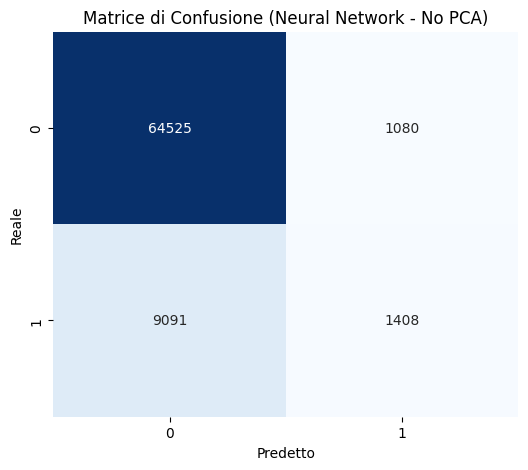

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     65605
           1       0.57      0.13      0.22     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.56      0.57     76104
weighted avg       0.83      0.87      0.83     76104



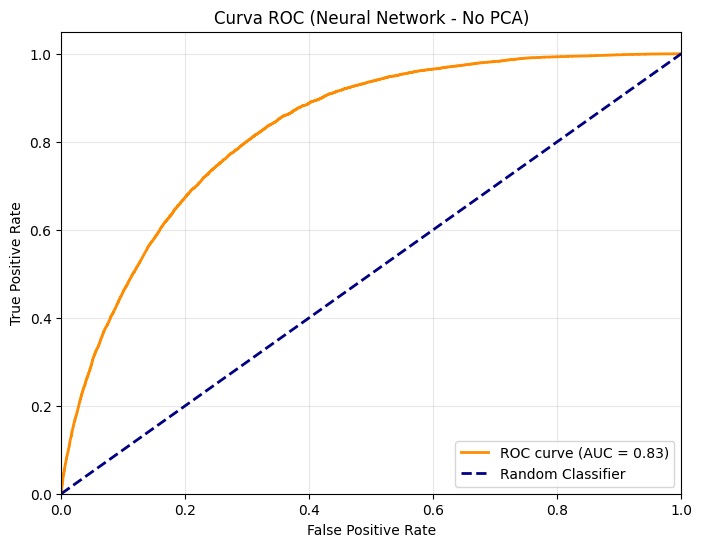


AUC Score: 0.8271


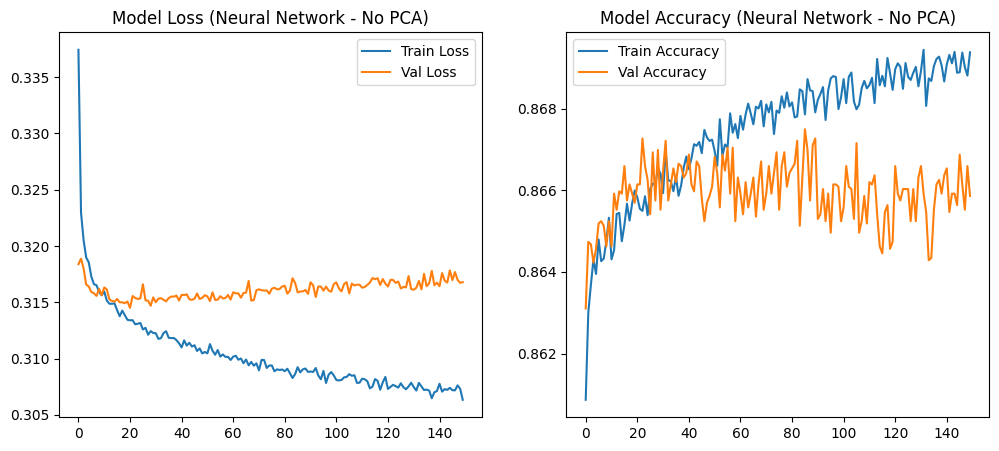

In [24]:
# 5. Valutazione
evaluate_and_plot(
    model, X_test, y_test, history, title_suffix="Neural Network - No PCA"
)

note: 
- fortemente dipendente dalla classe negativa (alto numero di veri e falsi negativi)
- ROC: valore >0.8 indica una buona separabilità delle classi: il modello distingue discretamente, seppur in maniera errata, gli esempi positivi da quelli negativi

- Training: validation loss non diverge in maniera marcata. Vi è un inizio di overfitting che però è controllato dal dropout

- come base di partenza il modello è stabile, ma in un contesto clinico come questo bisogna assolutamente ridurre il numero di falsi negativi

### Undersampling

#### Class Balancing

Viene costruito un dataset bilanciato selezionando in maniera casuale dalla classe maggioritaria (negativa) lo stesso numero di esempi della classe minoritaria (positiva). Viene eseguito uno shuffle e successivamente uno split 70/30 come precedentemente adottato. Il modello viene addestrato e valutato su un datset più piccolo, in cui entrambe le classi hanno la stessa probabilità, rimuovendo quindi lo sbilanciamento del dataset originale

In [25]:
# 1. Creazione dataset bilanciato (undersampling su tutto il dataset)

def balance_dataset(X, y):

    idx_minority = np.where(y == 1)[0]
    idx_majority = np.where(y == 0)[0]

    n_minority = len(idx_minority)

    idx_majority_downsampled = np.random.choice(
        idx_majority, size=n_minority, replace=False
    )

    idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
    np.random.shuffle(idx_balanced)

    return X[idx_balanced], y[idx_balanced]

In [26]:
X_bal, y_bal = balance_dataset(X, y)

print("Distribuzione classi nel dataset bilanciato:")
unique, counts = np.unique(y_bal, return_counts=True)
print(dict(zip(unique, counts)))

# 2. Train/test split sul dataset bilanciato
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

print("Distribuzione classi nel Training Set bilanciato:")
unique_tr, counts_tr = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique_tr, counts_tr)))

print("Distribuzione classi nel Test Set bilanciato:")
unique_te, counts_te = np.unique(y_test_bal, return_counts=True)
print(dict(zip(unique_te, counts_te)))

Distribuzione classi nel dataset bilanciato:
{np.int64(0): np.int64(35346), np.int64(1): np.int64(35346)}
Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24742), np.int64(1): np.int64(24742)}
Distribuzione classi nel Test Set bilanciato:
{np.int64(0): np.int64(10604), np.int64(1): np.int64(10604)}


L'architettura della rete presenta un numero di neuroni dimezzato per ogni layer rispetto a quella procedente, poichè si sta lavorando su una porzione del dataset di partenza 

In [27]:
# 3. Creazione del Modello
model_pca_under = Sequential()
model_pca_under.add(Dense(64, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_pca_under.add(Dropout(0.5))

model_pca_under.add(Dense(32, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(16, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(1, activation="sigmoid"))

model_pca_under.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento
history_pca_under = model_pca_under.fit(
    X_train_bal,
    y_train_bal,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/100


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6814 - loss: 0.5996 - val_accuracy: 0.7381 - val_loss: 0.5340
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7341 - loss: 0.5463 - val_accuracy: 0.7448 - val_loss: 0.5184
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7394 - loss: 0.5388 - val_accuracy: 0.7456 - val_loss: 0.5200
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7412 - loss: 0.5340 - val_accuracy: 0.7478 - val_loss: 0.5168
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7451 - loss: 0.5287 - val_accuracy: 0.7478 - val_loss: 0.5153
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7461 - loss: 0.5285 - val_accuracy: 0.7472 - val_loss: 0.5160
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7462 - loss: 0.5250 - val_accuracy: 0.7505 - val_loss: 0.5136
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7491 - loss: 0.5212 - val_accuracy: 0.7517

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step


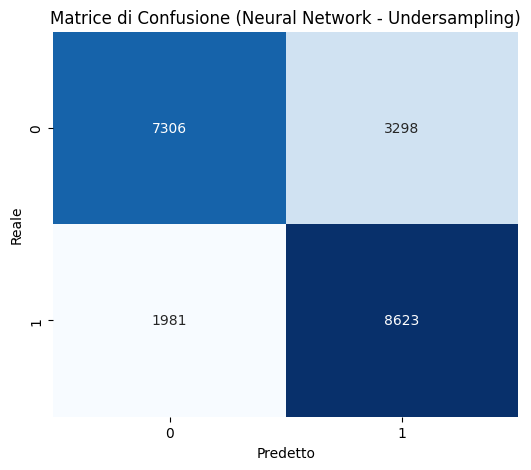

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73     10604
           1       0.72      0.81      0.77     10604

    accuracy                           0.75     21208
   macro avg       0.76      0.75      0.75     21208
weighted avg       0.76      0.75      0.75     21208



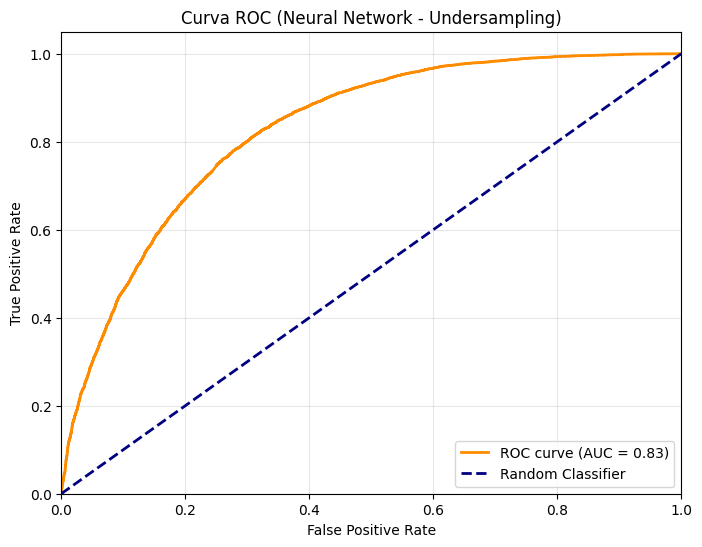


AUC Score: 0.8264


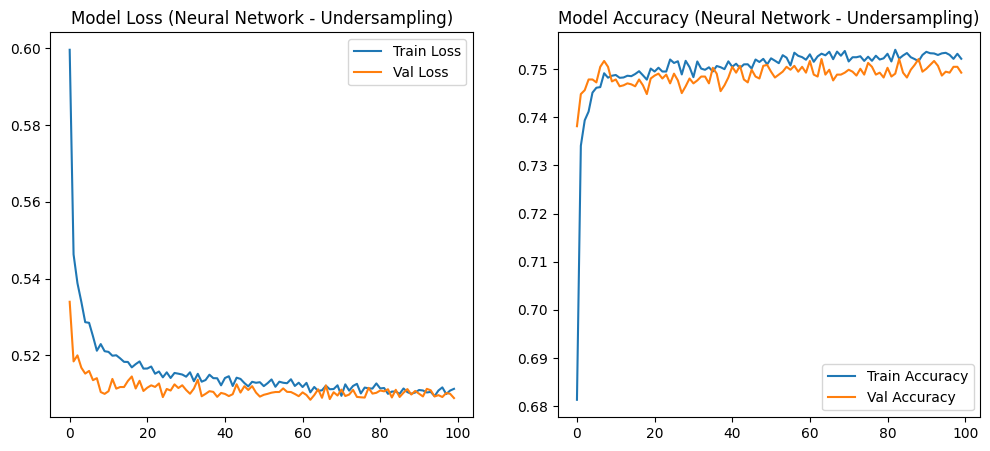

In [28]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_under,
    X_test_bal,
    y_test_bal,
    history_pca_under,
    title_suffix="Neural Network - Undersampling",
)

Trattando le classi alla pari, l'approccio con undersampling + class balancing ha reso il modello più stabile (le precision e recall medie sono notevolmente aumentate) e più tendente a classificare come positive le istanze (la percentuale di falsi negativi è molto minore a quella dei falsi positivi). La curva ROC è pressoché identica, segno che la capacità di classificazione non è cambiata. Train e Loss seguono lo stesso andamento, a prova del fatto che il modello è ora meno soggetto a overfitting grazie al bilanciamento delle classi 

### Class Weights

A partire dal dataset originale (senza undersampling), sono applicati pesi bilanciati per rendere più costosi gli errori sulla classe maggioritaria (positiva) e limitare la tendenza del modello a convergere nella direzione della classe dominante durante il training. L'architettura della rete ritorna alla sua composizione di partenza per lavorare sul dataset originale

In [29]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

model_no_pca_weighted = Sequential()

# Strati Nascosti
model_no_pca_weighted.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(64, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(32, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))

model_no_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6953 - loss: 0.5349 - val_accuracy: 0.6984 - val_loss: 0.5157
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7056 - loss: 0.5179 - val_accuracy: 0.7091 - val_loss: 0.5090
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7092 - loss: 0.5137 - val_accuracy: 0.7129 - val_loss: 0.5053
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7132 - loss: 0.5119 - val_accuracy: 0.7162 - val_loss: 0.5059
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7132 - loss: 0.5101 - val_accuracy: 0.7193 - val_loss: 0.5053
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7189 - loss: 0.5088 - val_accuracy: 0.7133 - val_loss: 0.5216
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7206 - loss: 0.5091 - val_accuracy: 0.7129 - val_loss: 0.5147
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7210 - loss: 0.5081 - val_accuracy: 0.7244

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 753us/step


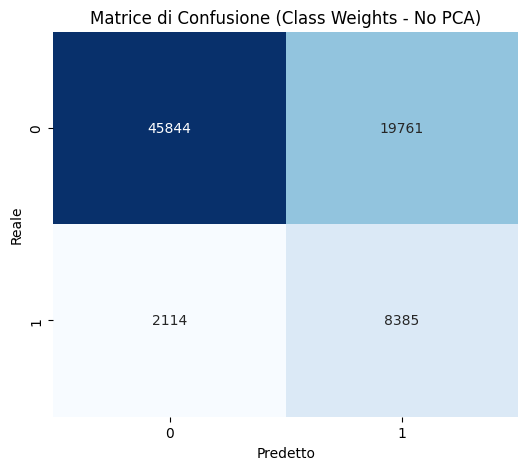

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     65605
           1       0.30      0.80      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.76     76104



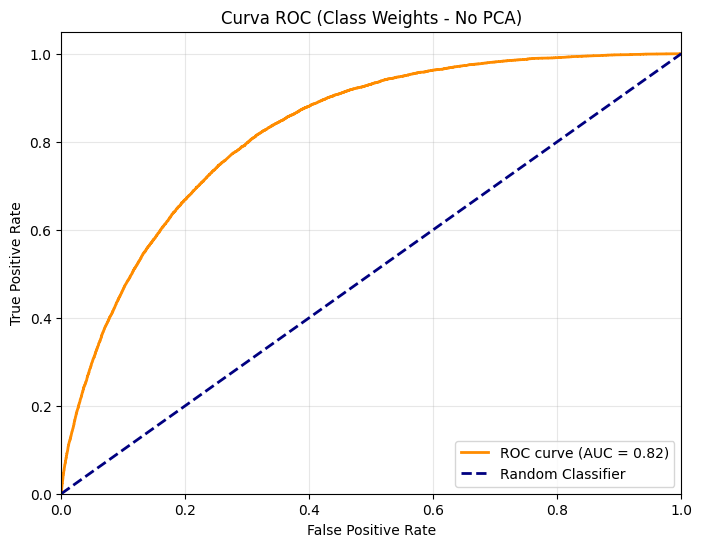


AUC Score: 0.8249


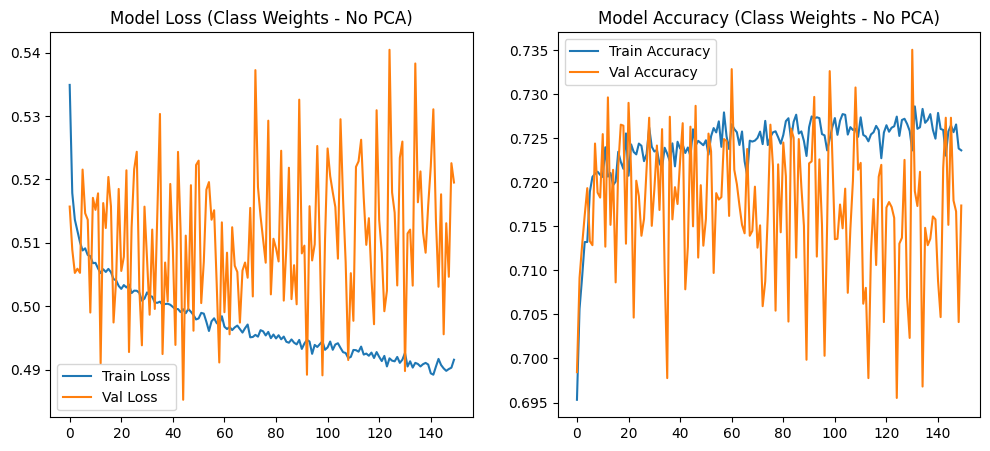

In [30]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_weighted,
    X_test,
    y_test,
    history_no_pca_weighted,
    title_suffix="Class Weights - No PCA",
)

L'approccio con Class Weights ottiene un recall dei positivi ancora a 0.78, quindi paragonabile all'undersampling, ma con una precisione più bassa (0.31) e curve di validazione più rumorose che tendono a divergere leggermente dal train. Questo rumore suggerisce che il modello oscilla nel trovare l'equilibrio tra i pesi, ma comunque riesce a limitare la tendenza del modello originale a sbilanciarsi verso la classe maggioritaria, come nel caso dell'undersampling. Infatti, guardando la matrice di confusione si nota una grande somiglianza con l'approccio `undersampling + class balancing`: meno FN e più FP rispetto al modello base, ma senza la perdita di informazione dovuta al undersampling stesso.

### Focal Loss
Va leggermente meglio (non so quanto, da analizzare...) però ha un maggior onere computazionale.
A livello di tempi Class Weights è molto più veloce.

In [31]:
# Definizione corretta della Focal Loss per classificazione binaria
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss per classificazione binaria sbilanciata.

    Parameters:
    - gamma: focusing parameter (default=2.0). Maggiore è gamma, più il modello si concentra sugli esempi difficili
    - alpha: peso per la classe positiva (default=0.25). Per dati sbilanciati, usa alpha ≈ frequenza classe negativa
    """

    def focal_loss_fixed(y_true, y_pred):
        # Converti tutto a float32 per evitare problemi di tipo
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Binary Cross Entropy
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

        # Focal Loss modulation
        # Per gli esempi della classe 1 (y_true=1): p_t = y_pred
        # Per gli esempi della classe 0 (y_true=0): p_t = 1 - y_pred
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)

        # Alpha balancing (converti alpha a float32)
        alpha_f32 = tf.constant(alpha, dtype=tf.float32)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha_f32, 1 - alpha_f32)

        # Focal term: (1 - p_t)^gamma (converti gamma a float32)
        gamma_f32 = tf.constant(gamma, dtype=tf.float32)
        focal_weight = tf.pow(1.0 - p_t, gamma_f32)

        # Focal Loss finale
        focal_loss = alpha_t * focal_weight * bce

        return tf.reduce_mean(focal_loss)

    return focal_loss_fixed

In [32]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
class_freq_np = np.bincount(y_train.astype(int))
alpha_optimal_np = float(class_freq_np[0] / (class_freq_np[0] + class_freq_np[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal_np:.3f}")

# 2. Creazione del Modello
model_no_pca_focal = Sequential()

# Strati Nascosti
model_no_pca_focal.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(64, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

model_no_pca_focal.add(Dense(32, activation="relu"))
model_no_pca_focal.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
model_no_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal_np),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_no_pca_focal = model_no_pca_focal.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6893 - loss: 0.0338 - val_accuracy: 0.6715 - val_loss: 0.0321
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6973 - loss: 0.0322 - val_accuracy: 0.7037 - val_loss: 0.0319
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7028 - loss: 0.0319 - val_accuracy: 0.7016 - val_loss: 0.0317
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7086 - loss: 0.0317 - val_accuracy: 0.7118 - val_loss: 0.0316
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7133 - loss: 0.0316 - val_accuracy: 0.7187 - val_loss: 0.0316
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7171 - loss: 0.0316 - val_accuracy: 0.7015 - val_loss: 0.0315
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7161 - loss: 0.0315 - val_accuracy: 0.7114 - val_loss: 0.0315
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7167 - loss: 0.0315 - val_accuracy: 0.7122

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


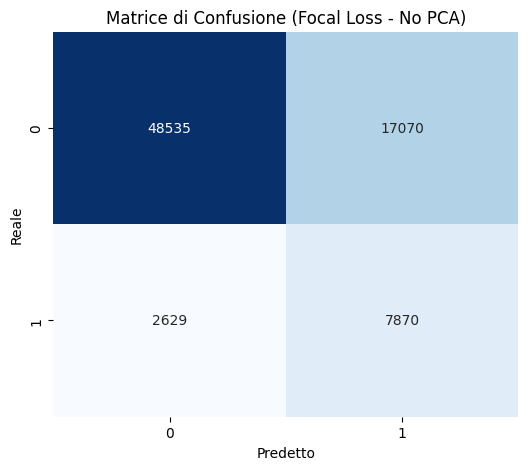

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     65605
           1       0.32      0.75      0.44     10499

    accuracy                           0.74     76104
   macro avg       0.63      0.74      0.64     76104
weighted avg       0.86      0.74      0.78     76104



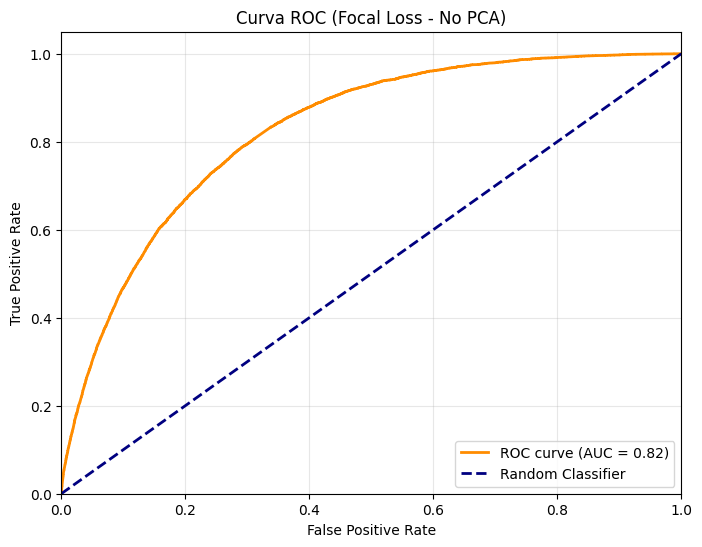


AUC Score: 0.8244


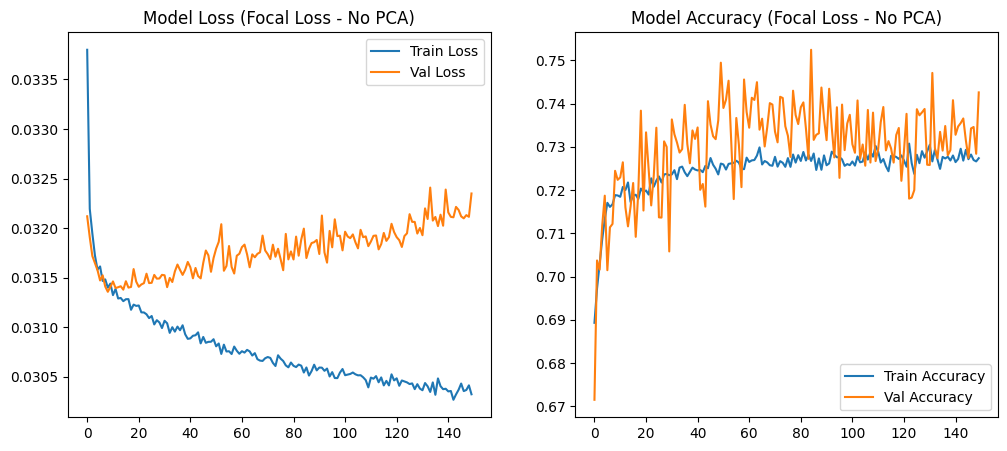

In [33]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_focal,
    X_test,
    y_test,
    history_no_pca_focal,
    title_suffix="Focal Loss - No PCA",
)

## PCA

### Class Weights

Considerando le componenti principali estratte dalla PCA, viene adottato il class weight sul dataset originale

In [34]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_pca), y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(16, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(8, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_pca_weighted.add(Dense(1, activation="sigmoid"))

model_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6530 - loss: 0.6104 - val_accuracy: 0.6903 - val_loss: 0.5182
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7035 - loss: 0.5661 - val_accuracy: 0.7062 - val_loss: 0.5084
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7048 - loss: 0.5564 - val_accuracy: 0.7140 - val_loss: 0.4979
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7072 - loss: 0.5511 - val_accuracy: 0.7101 - val_loss: 0.5028
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7053 - loss: 0.5489 - val_accuracy: 0.6941 - val_loss: 0.5195
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7038 - loss: 0.5465 - val_accuracy: 0.7016 - val_loss: 0.5054
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7029 - loss: 0.5433 - val_accuracy: 0.6960 - val_loss: 0.5138
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7069 - loss: 0.5437 - val_accuracy: 0.7035

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 831us/step


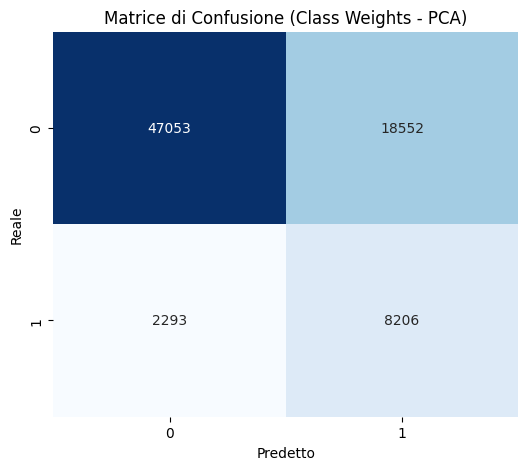

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     65605
           1       0.31      0.78      0.44     10499

    accuracy                           0.73     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.86      0.73      0.77     76104



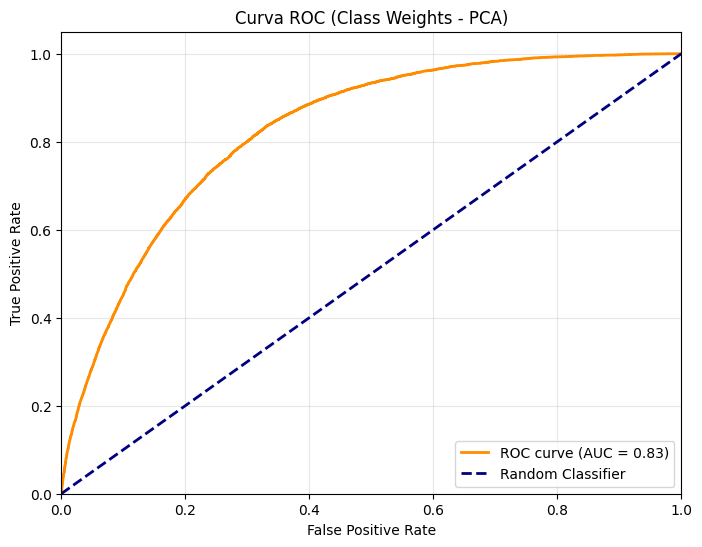


AUC Score: 0.8250


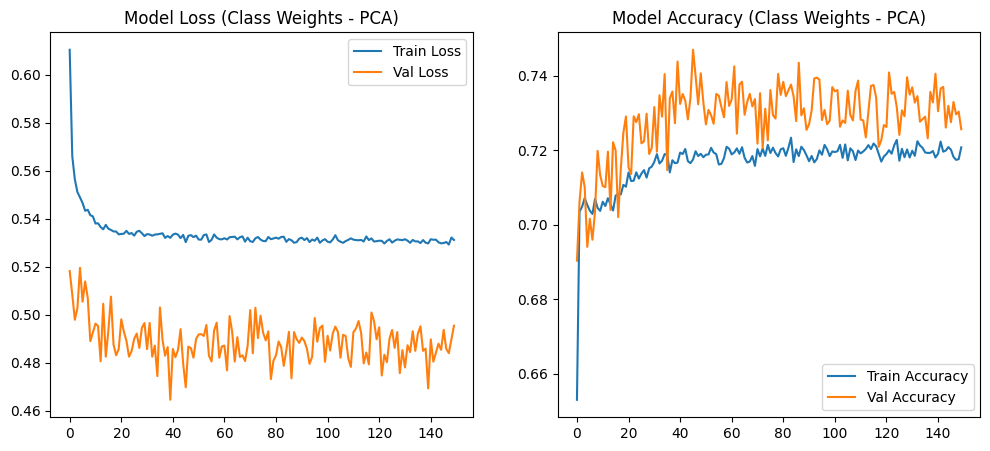

In [35]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_weighted,
    X_test_pca,
    y_test_pca,
    history_pca_weighted,
    title_suffix="Class Weights - PCA",
)

Rispetto al suo equivalente senza PCA, il modello sacrifica il numero dei FP e l'accuratezza generale in favore della massimizzazione della sensabilità sulla classe negativa. 
NOTE: modelli utili in entrambi i contesti d'uso:
- attenzione nel "non-perdersi" individui positivi: preferire PCA + class weight
- attenzione nel ridurre i "falsi allarmi": preferire no PCA + class weight

### Focal Loss
Direi di togliere questa parte, non porta miglioramenti significativi.

In [36]:
# Calcola alpha ottimale basato sulla distribuzione delle classi
# alpha ≈ freq(classe 0) per dare più peso alla classe minoritaria (1)
class_freq = np.bincount(y_train_pca.astype(int))
alpha_optimal = float(class_freq[0] / (class_freq[0] + class_freq[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal:.3f}")

# 2. Creazione del Modello
model_pca_focal = Sequential()

model_pca_focal.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(16, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(8, activation="relu"))
model_pca_focal.add(Dropout(0.3))

model_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
# Usa gamma=2.0 e alpha calcolato automaticamente
model_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal),
    optimizer="adam",
    metrics=["accuracy"],
)

# 4. Addestramento
history_pca_focal = model_pca_focal.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
)

Alpha ottimale calcolato: 0.860
Epoch 1/150


C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6535 - loss: 0.0375 - val_accuracy: 0.6702 - val_loss: 0.0336
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6775 - loss: 0.0346 - val_accuracy: 0.6799 - val_loss: 0.0328
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6642 - loss: 0.0338 - val_accuracy: 0.6991 - val_loss: 0.0325
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6752 - loss: 0.0337 - val_accuracy: 0.7009 - val_loss: 0.0323
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6826 - loss: 0.0334 - val_accuracy: 0.7048 - val_loss: 0.0323
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6876 - loss: 0.0334 - val_accuracy: 0.6999 - val_loss: 0.0323
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7037 - loss: 0.0332 - val_accuracy: 0.7094 - val_loss: 0.0323
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7046 - loss: 0.0330 - val_accuracy: 0.6947

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 803us/step


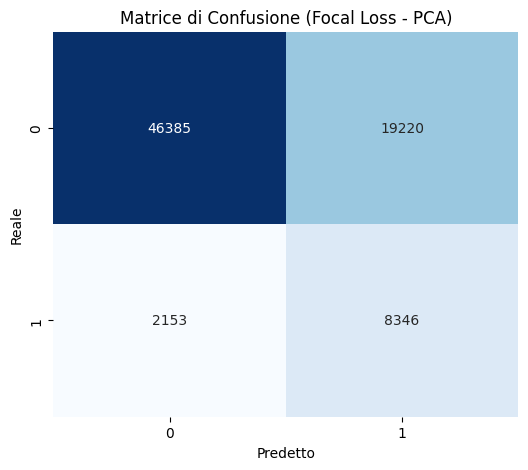

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     65605
           1       0.30      0.79      0.44     10499

    accuracy                           0.72     76104
   macro avg       0.63      0.75      0.63     76104
weighted avg       0.87      0.72      0.76     76104



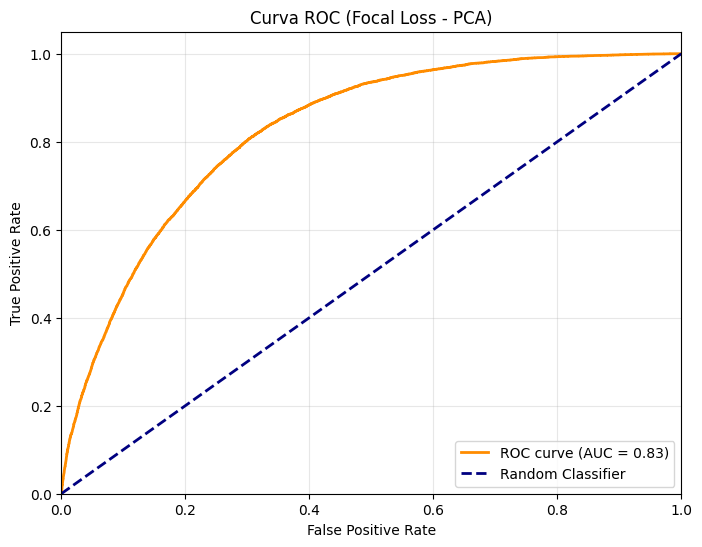


AUC Score: 0.8252


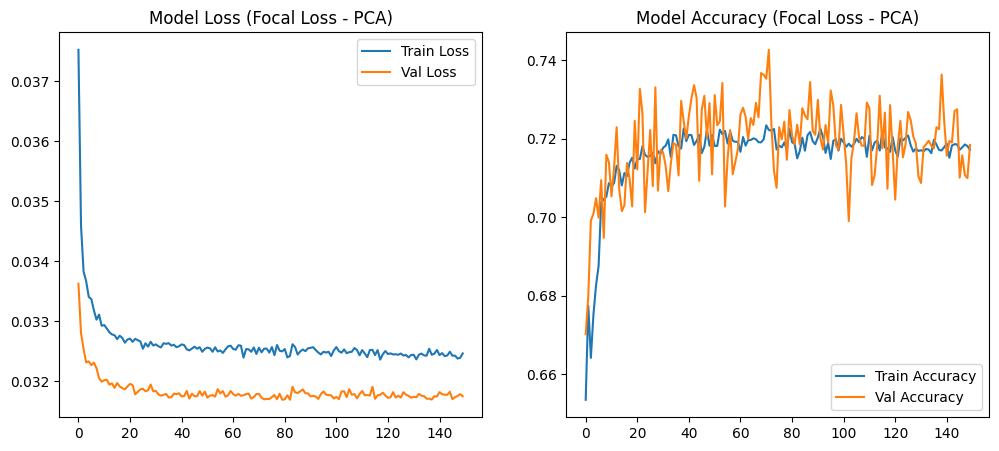

In [37]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_focal,
    X_test_pca,
    y_test_pca,
    history_pca_focal,
    title_suffix="Focal Loss - PCA",
)

# Decision Tree

In [38]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree


def show_tree_metrics(tree, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    if hasattr(tree, "get_depth"):
      print(f"Profondità albero: {tree.get_depth()}")
      print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione"
    plt.title(title)
    plt.show()

    print("\n" + classification_report(y_test, y_pred))

def print_tree(tree, max_depth, title):
    plt.figure(figsize=(25, 12))
    plot_tree(
        tree,
        filled=True,
        feature_names=numeric_features,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

## No PCA

### No Pruning

Accuracy: 0.7980
Profondità albero: 38
Numero di foglie: 32829


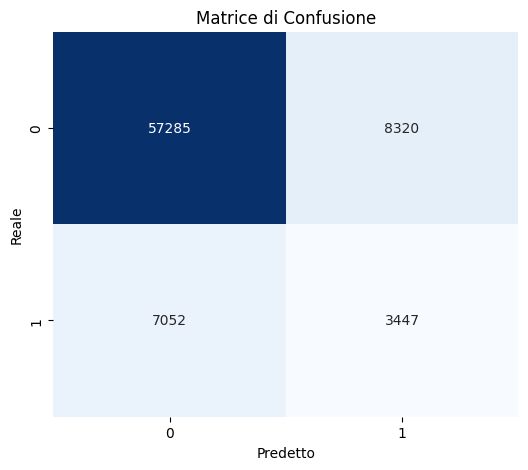


              precision    recall  f1-score   support

           0       0.89      0.87      0.88     65605
           1       0.29      0.33      0.31     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.60     76104
weighted avg       0.81      0.80      0.80     76104



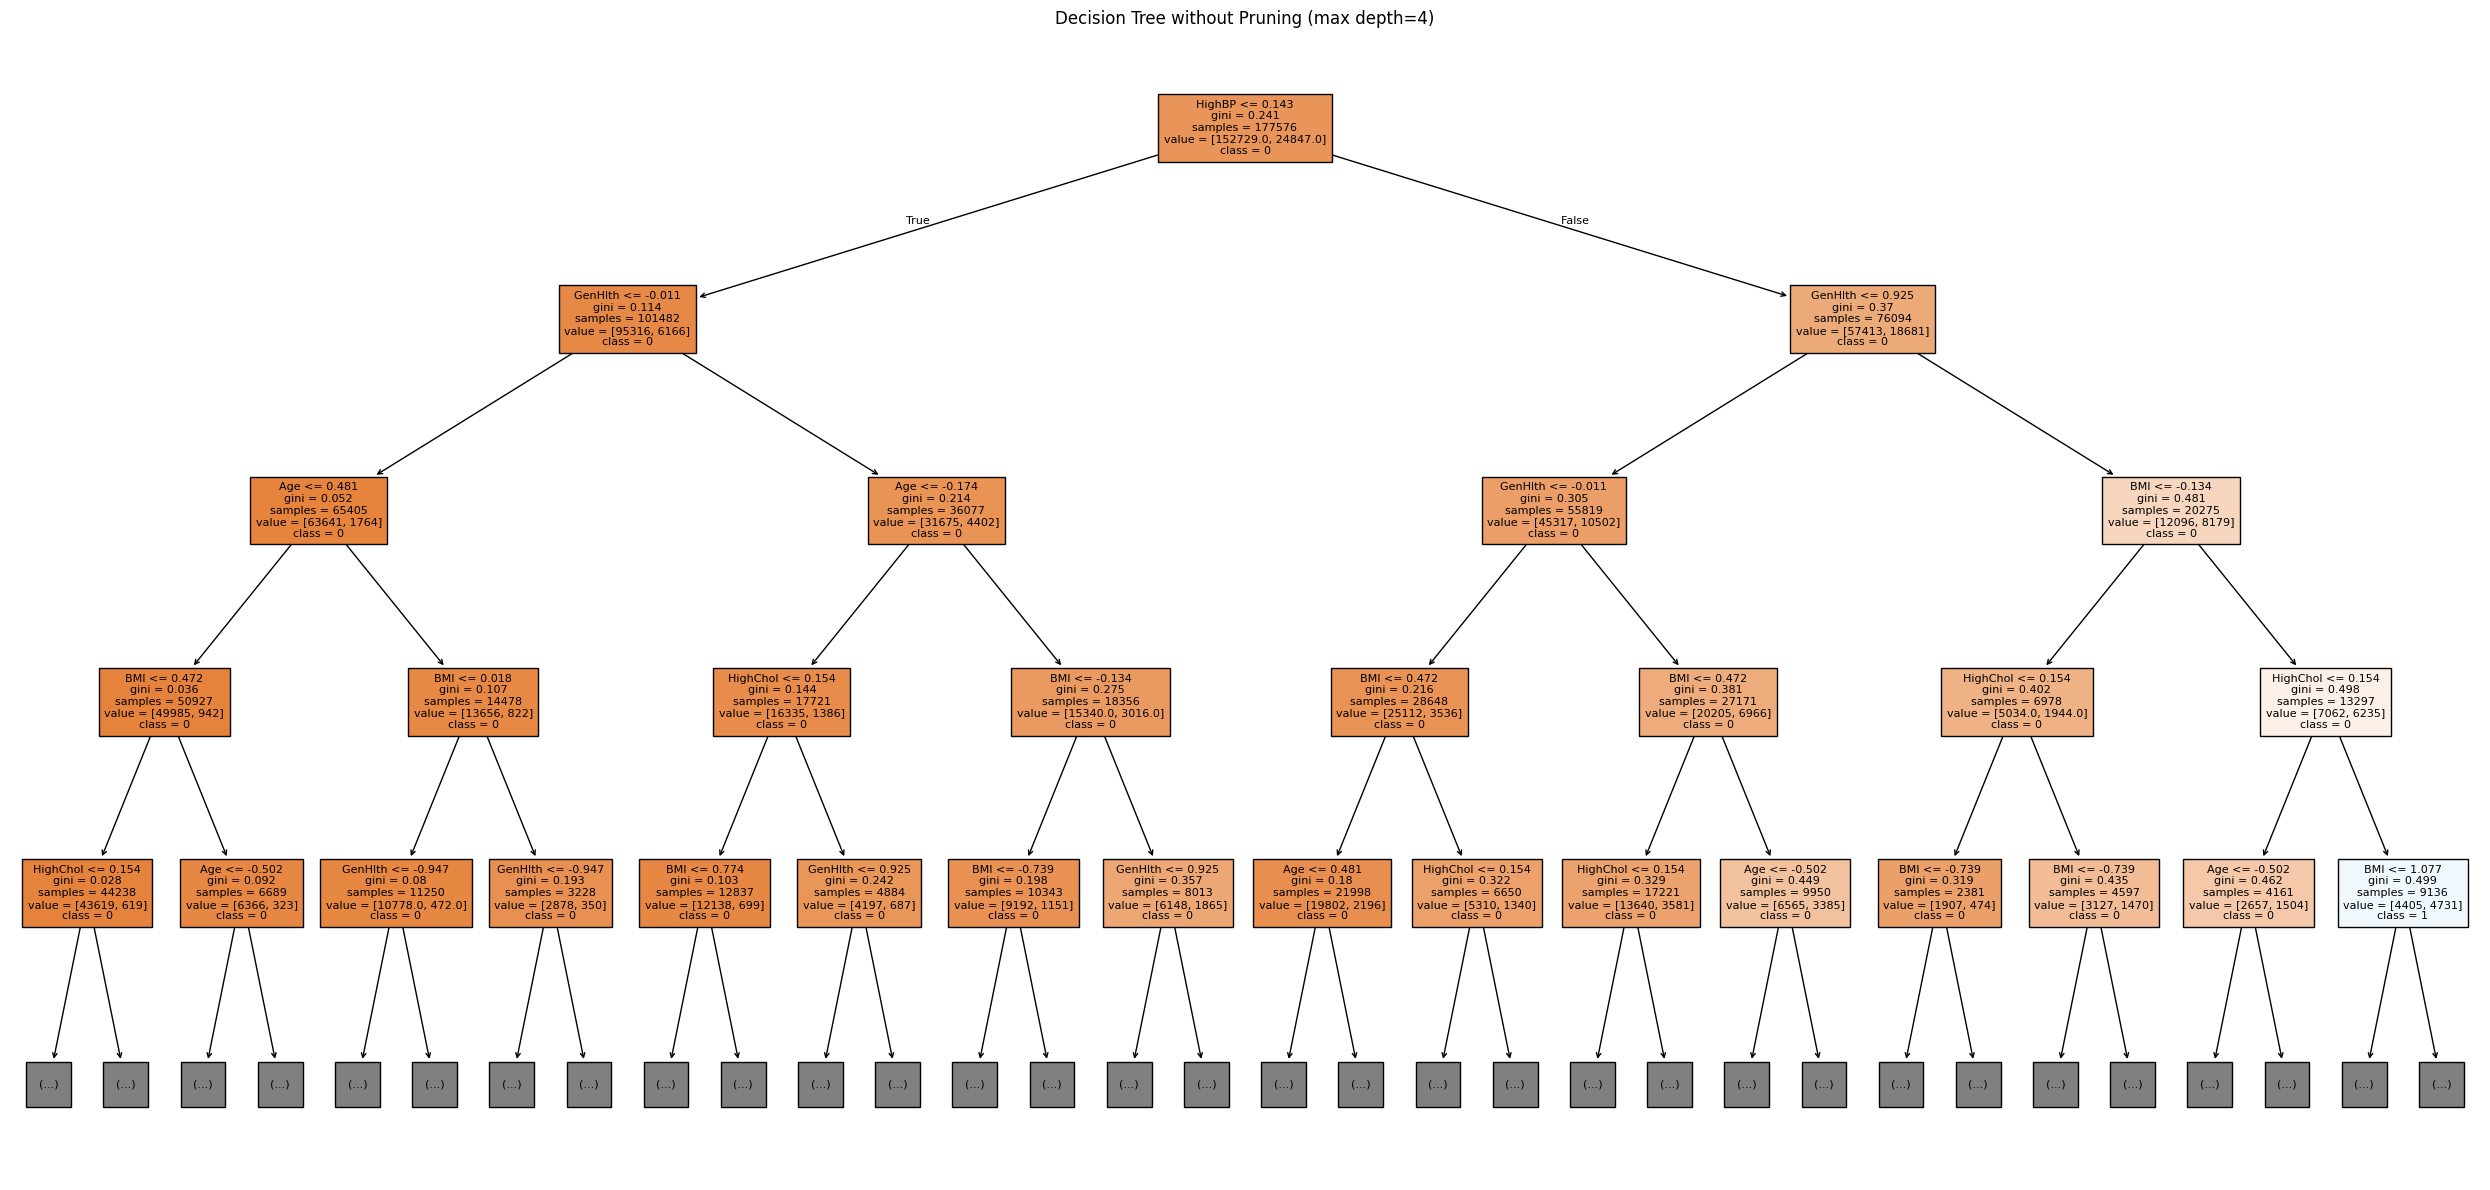

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt_no_pruning = DecisionTreeClassifier(random_state=42)
dt_no_pruning.fit(X_train, y_train)

y_pred_no_prune = dt_no_pruning.predict(X_test)

show_tree_metrics(dt_no_pruning, y_test, y_pred_no_prune)
print_tree(dt_no_pruning, 4, "Decision Tree without Pruning (max depth=4)")

Accuracy: 0.6582
Profondità albero: 36
Numero di foglie: 14091


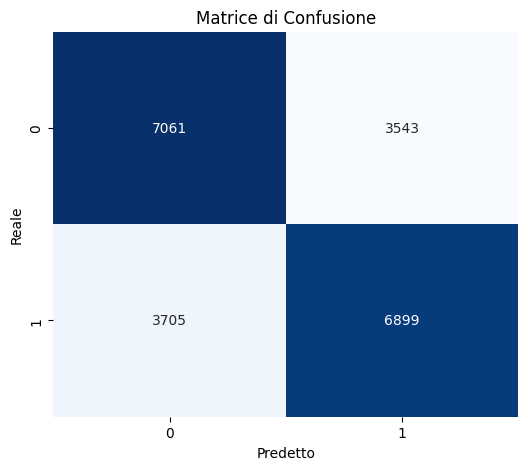


              precision    recall  f1-score   support

           0       0.66      0.67      0.66     10604
           1       0.66      0.65      0.66     10604

    accuracy                           0.66     21208
   macro avg       0.66      0.66      0.66     21208
weighted avg       0.66      0.66      0.66     21208



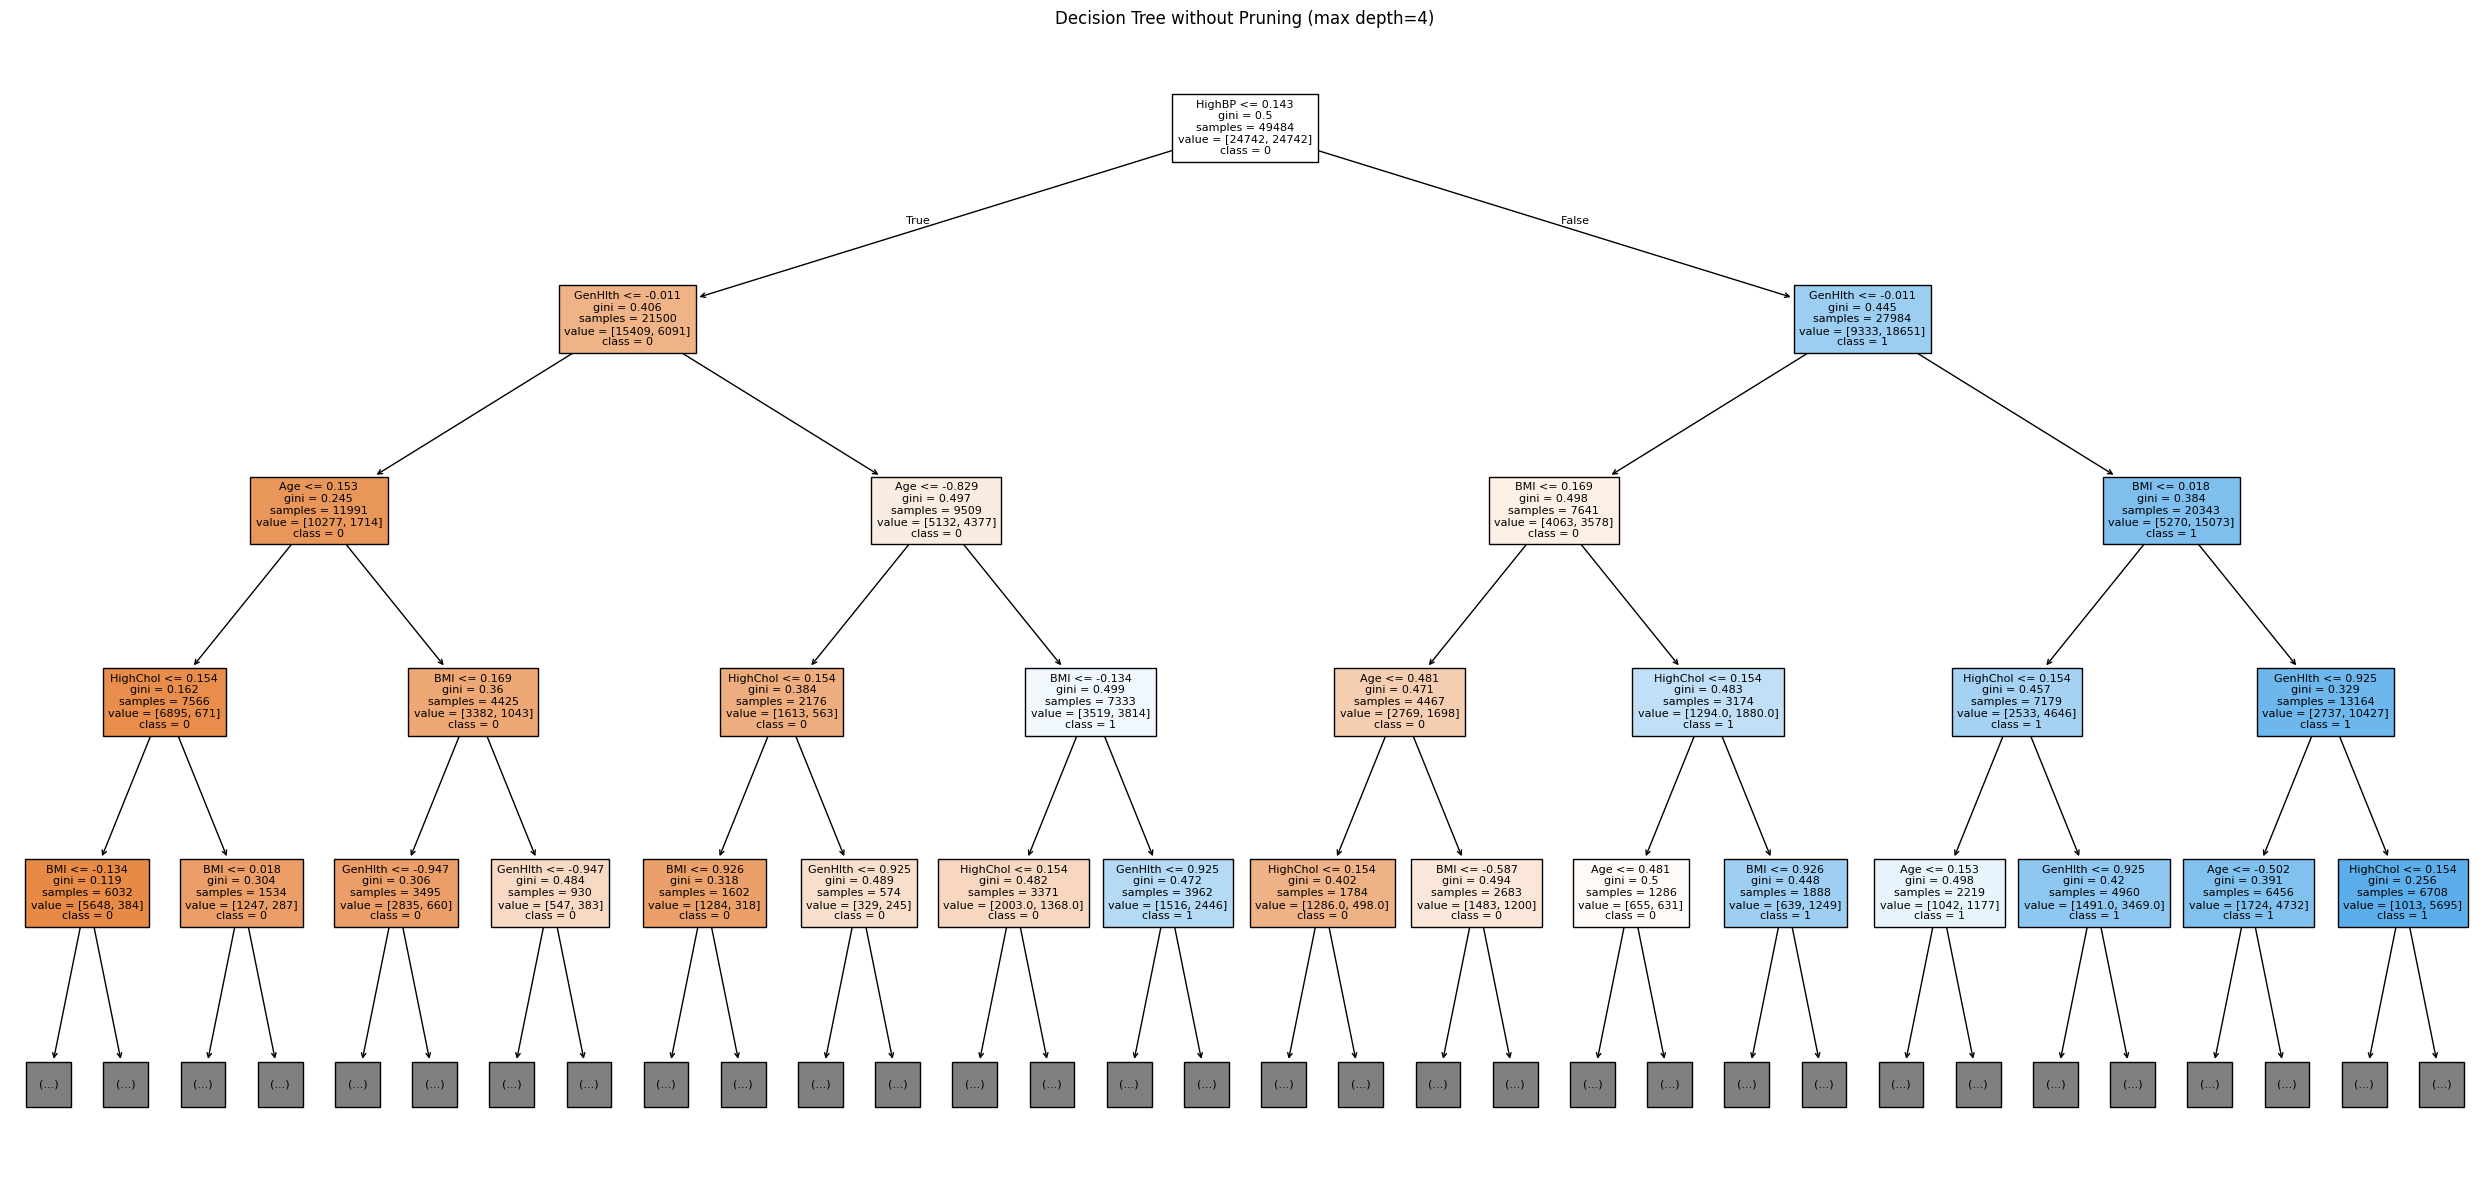

In [46]:
X_bal, y_bal = balance_dataset(X, y)

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

dt_no_pruning_bal = DecisionTreeClassifier(random_state=42)
dt_no_pruning_bal.fit(X_train_bal, y_train_bal)

y_pred_no_prune_bal = dt_no_pruning_bal.predict(X_test_bal)

show_tree_metrics(dt_no_pruning_bal, y_test_bal, y_pred_no_prune_bal)
print_tree(dt_no_pruning_bal, 4, "Decision Tree without Pruning (max depth=4)")

Random Forests

Accuracy: 0.8572


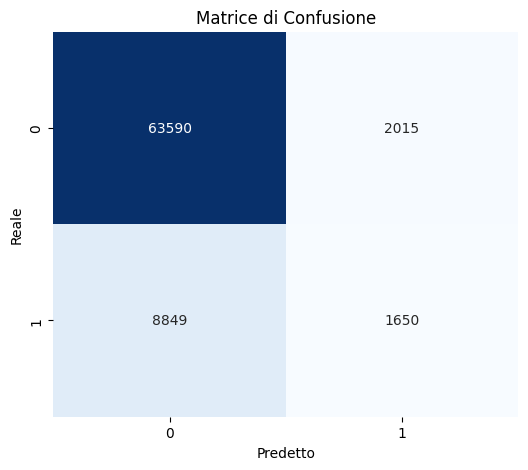


              precision    recall  f1-score   support

           0       0.88      0.97      0.92     65605
           1       0.45      0.16      0.23     10499

    accuracy                           0.86     76104
   macro avg       0.66      0.56      0.58     76104
weighted avg       0.82      0.86      0.83     76104



In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

show_tree_metrics(model, y_test, y_pred)

### With Pruning

Accuracy: 0.8654
Profondità albero: 8
Numero di foglie: 33


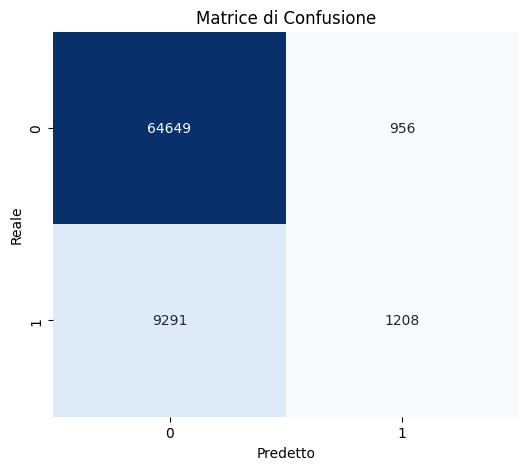


              precision    recall  f1-score   support

           0       0.87      0.99      0.93     65605
           1       0.56      0.12      0.19     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.55      0.56     76104
weighted avg       0.83      0.87      0.83     76104



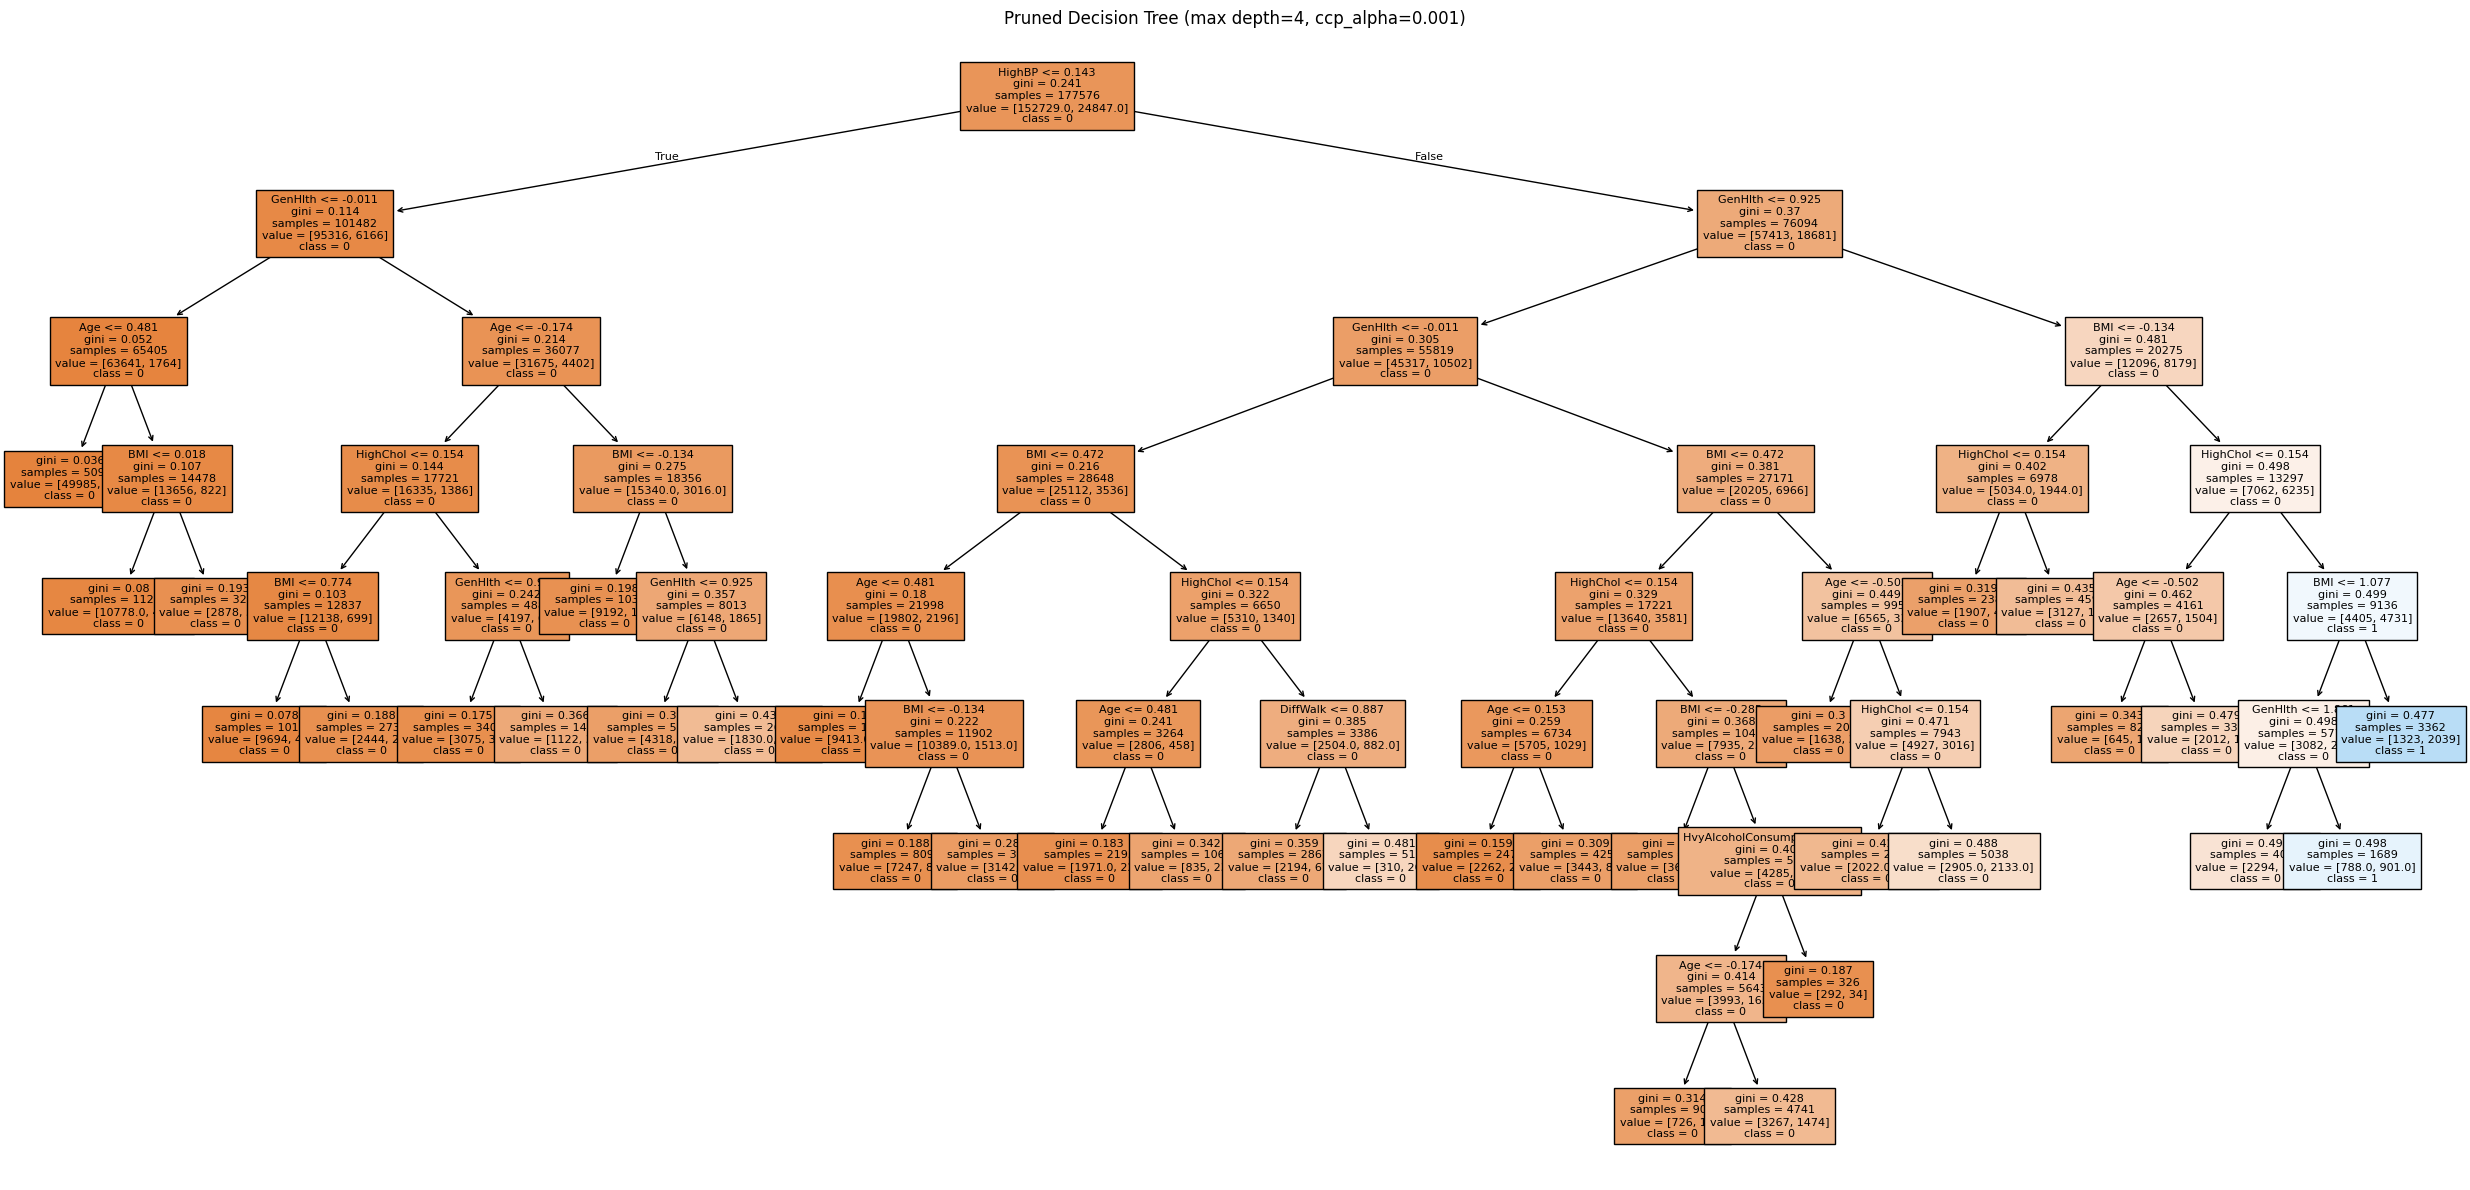

In [41]:
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
show_tree_metrics(dt_pruned, y_test, y_pred_pruned)
print_tree(dt_pruned, dt_pruned.get_depth(), "Pruned Decision Tree (max depth=4, ccp_alpha=0.001)")

## PCA

### No Pruning

Accuracy: 0.8008
Profondità albero: 50
Numero di foglie: 19037


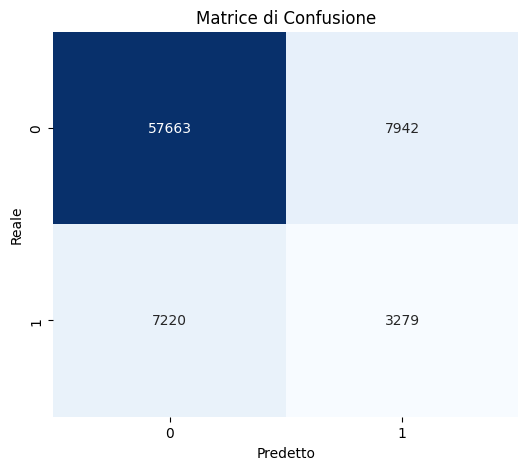


              precision    recall  f1-score   support

           0       0.89      0.88      0.88     65605
           1       0.29      0.31      0.30     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.59     76104
weighted avg       0.81      0.80      0.80     76104



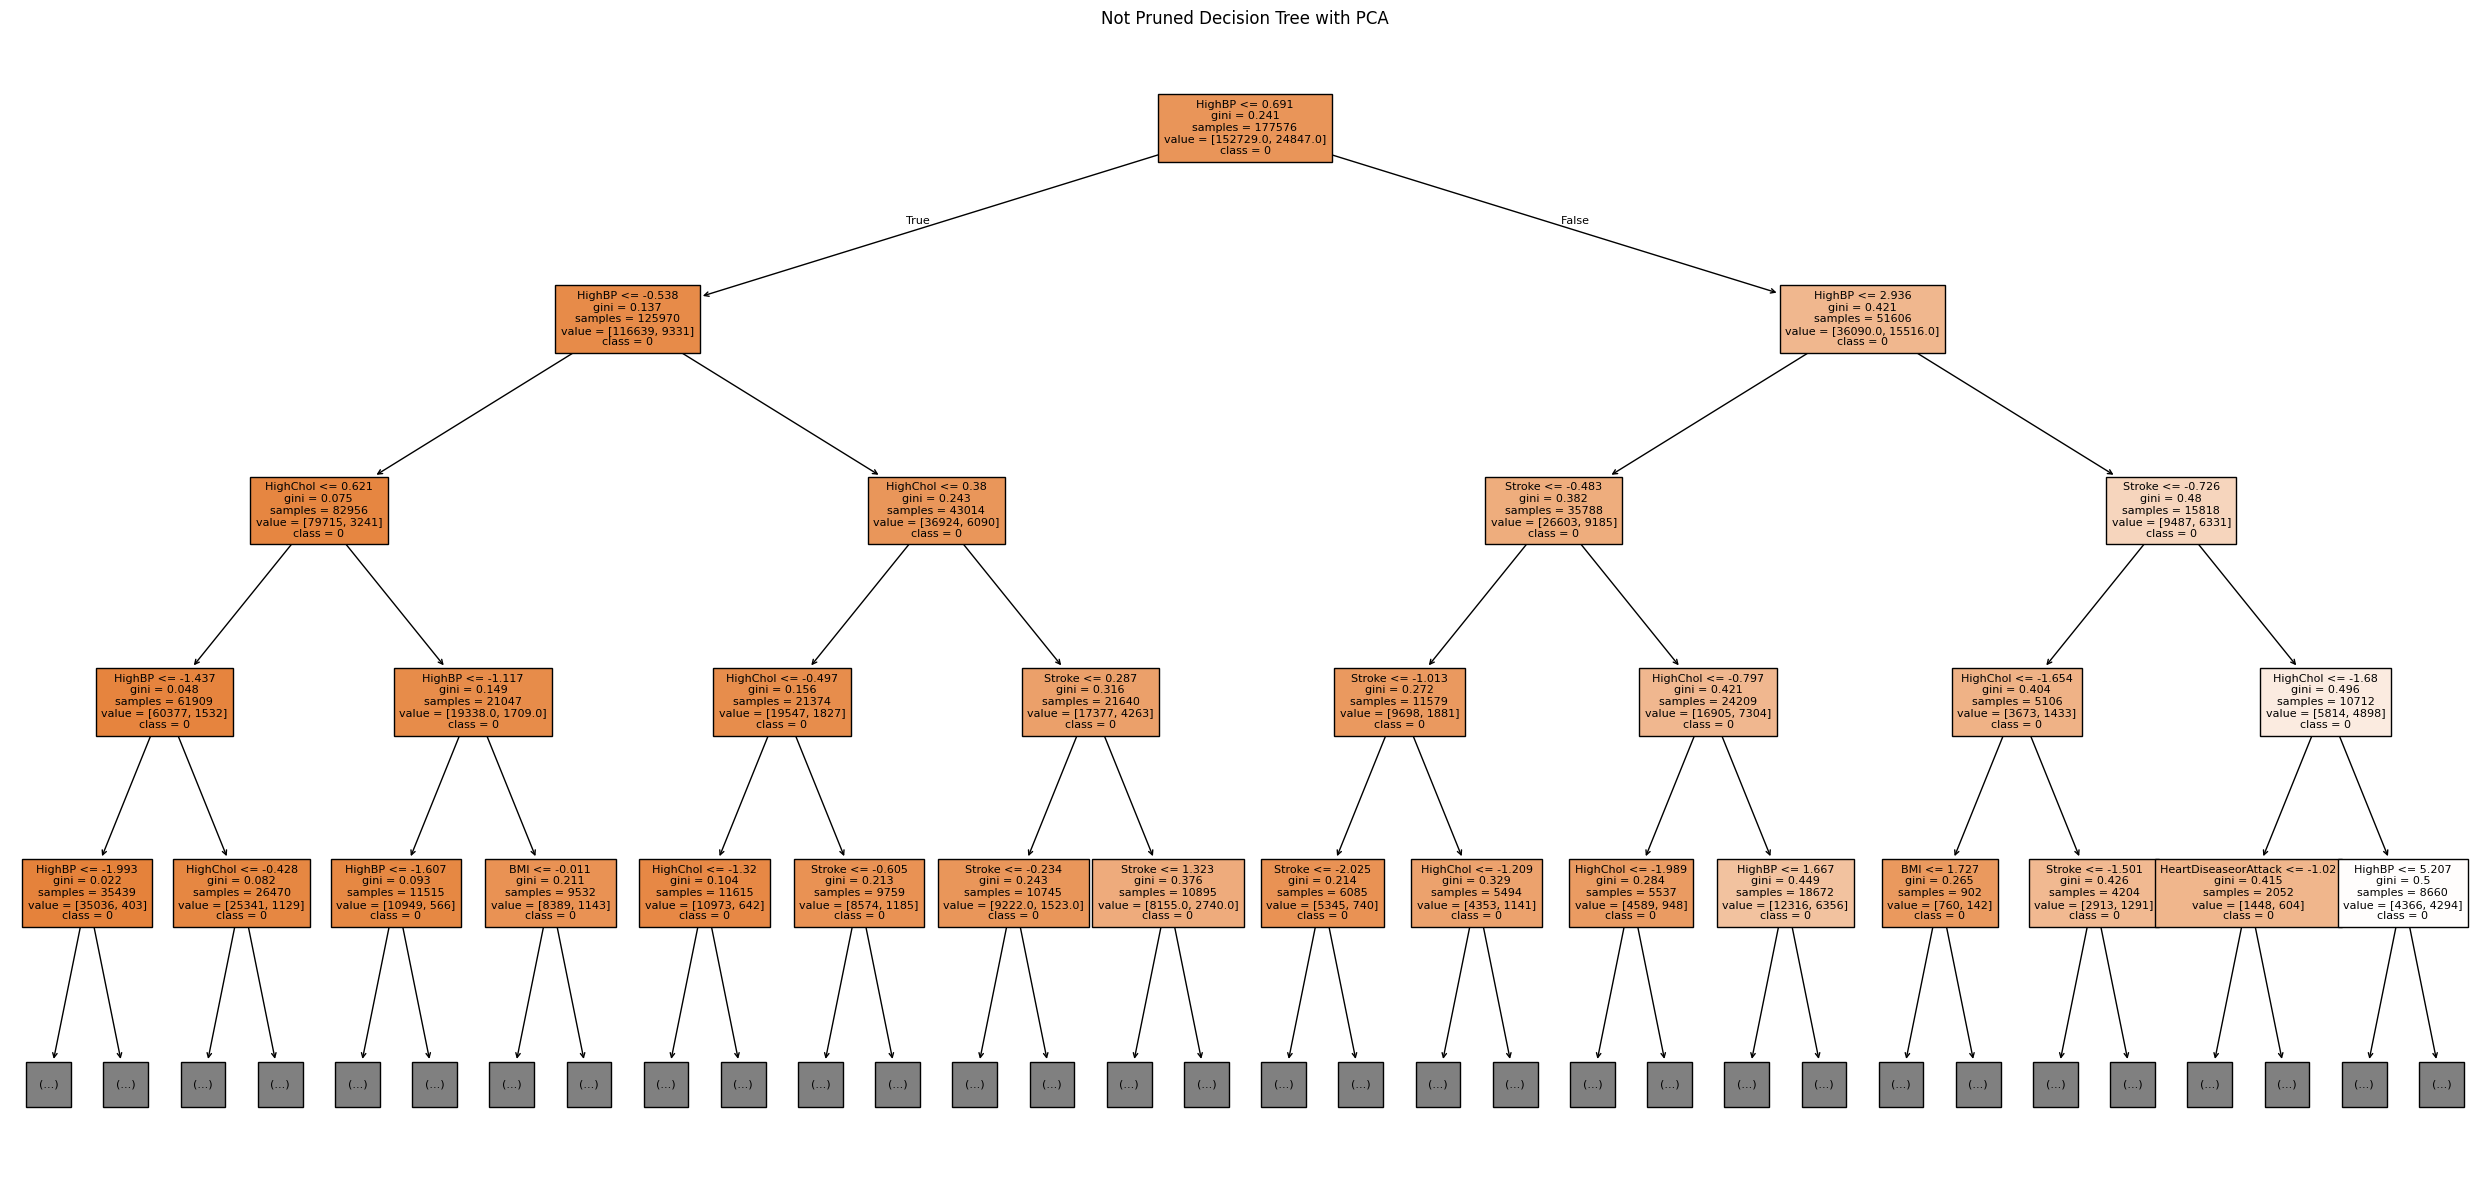

In [42]:
dt_pca_no_pruned = DecisionTreeClassifier(random_state=42)
dt_pca_no_pruned.fit(X_train_pca, y_train_pca)

y_pred_no_pruned = dt_pca_no_pruned.predict(X_test_pca)
show_tree_metrics(dt_pca_no_pruned, y_test_pca, y_pred_no_pruned)
print_tree(dt_pca_no_pruned, 4, "Not Pruned Decision Tree with PCA")

### With Pruning

Accuracy: 0.8629
Profondità albero: 7
Numero di foglie: 36


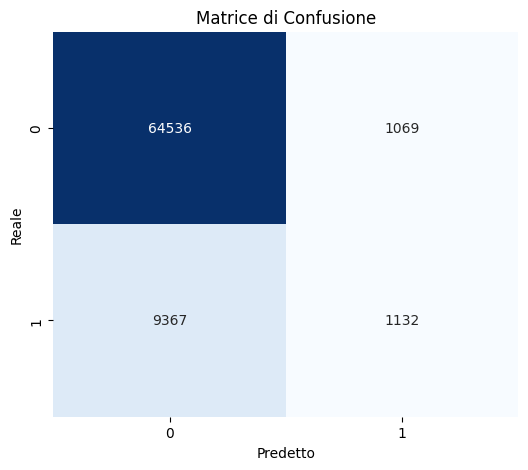


              precision    recall  f1-score   support

           0       0.87      0.98      0.93     65605
           1       0.51      0.11      0.18     10499

    accuracy                           0.86     76104
   macro avg       0.69      0.55      0.55     76104
weighted avg       0.82      0.86      0.82     76104



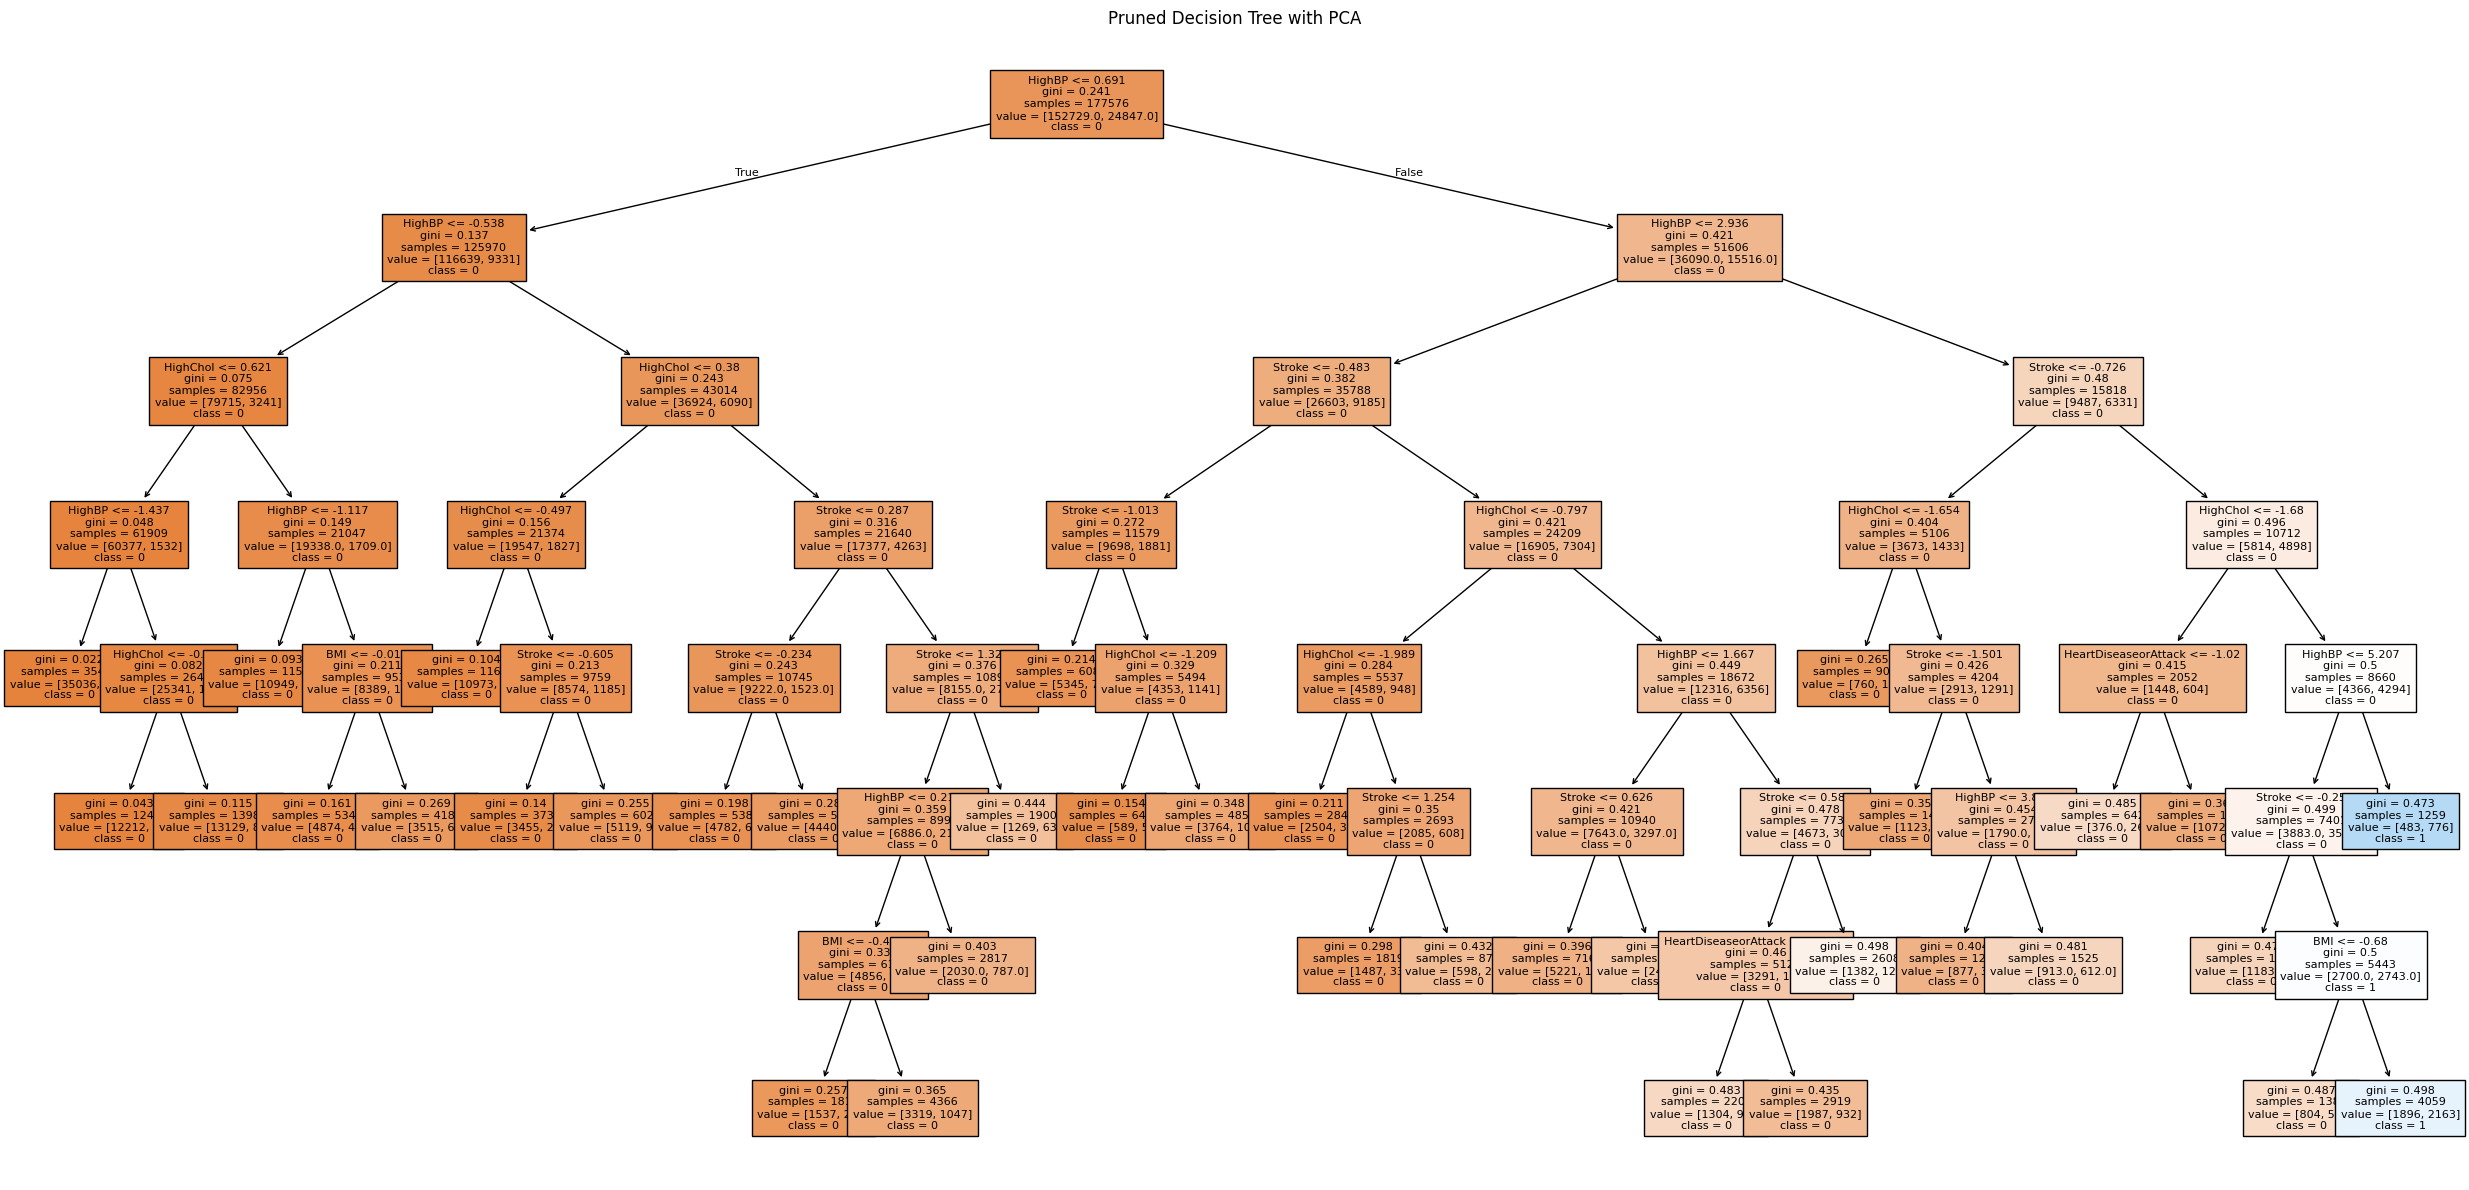

In [43]:
dt_pca_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001)
dt_pca_pruned.fit(X_train_pca, y_train_pca)

y_pred_pruned = dt_pca_pruned.predict(X_test_pca)
show_tree_metrics(dt_pca_pruned, y_test_pca, y_pred_pruned)
print_tree(dt_pca_pruned, dt_pca_pruned.get_depth(), "Pruned Decision Tree with PCA")

# Support Vector Machines

In [44]:
def show_metrics_svm(model, y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Opzionale: Se il modello è un SVC (non LinearSVC), possiamo stampare i vettori di supporto
    if hasattr(model, 'n_support_'):
        print(f"Numero di vettori di supporto: {sum(model.n_support_)}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.title("Matrice di Confusione (SVM)")
    plt.show()

    print("\n" + classification_report(y_test, y_pred))

## Linear Kernel

In [45]:
from sklearn.svm import LinearSVC, SVC

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

show_metrics_svm(svm_linear, y_test, y_pred_linear)


KeyboardInterrupt: 

## Kernel RBF

Accuracy: 0.8648
Numero di vettori di supporto: 3566


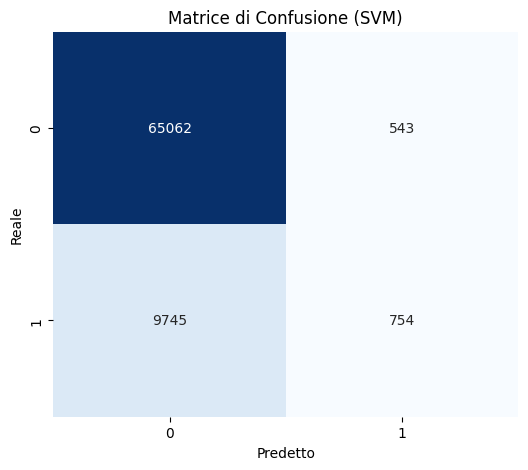


              precision    recall  f1-score   support

           0       0.87      0.99      0.93     65605
           1       0.58      0.07      0.13     10499

    accuracy                           0.86     76104
   macro avg       0.73      0.53      0.53     76104
weighted avg       0.83      0.86      0.82     76104



In [ ]:
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train_small, y_train_small)
y_pred_rbf = svm_rbf.predict(X_test)

show_metrics_svm(svm_rbf, y_test, y_pred_rbf)

## Polynomial Kernel

Accuracy: 0.7505
Numero di vettori di supporto: 5670


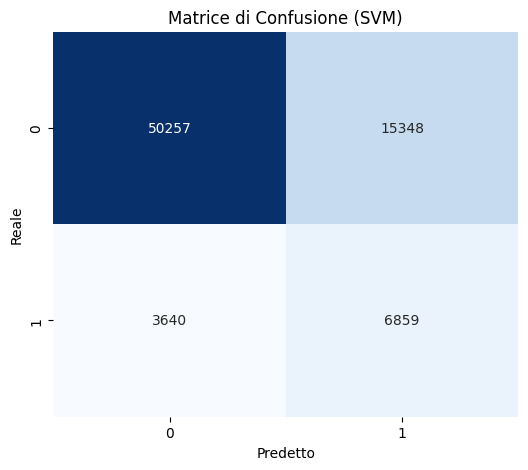


              precision    recall  f1-score   support

           0       0.93      0.77      0.84     65605
           1       0.31      0.65      0.42     10499

    accuracy                           0.75     76104
   macro avg       0.62      0.71      0.63     76104
weighted avg       0.85      0.75      0.78     76104



In [ ]:
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42, class_weight='balanced')
svm_poly.fit(X_train_small, y_train_small)
y_pred_poly = svm_poly.predict(X_test)

show_metrics_svm(svm_poly, y_test, y_pred_poly)